<a href="https://colab.research.google.com/github/Dareen-Aiman/E-Commerce-Profit-Analysis/blob/main/E_Commerce_Profitability_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project: E-commerce Customer Behavior & Revenue Analysis**

# Goal: Evaluate profitability trends and the impact of discount strategies.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [ ]:
# Load the dataset (Ensuring the correct encoding for CSV files)
df = pd.read_csv('E-Commerce Data.csv', encoding='windows-1252')

# Initial inspection to verify columns and data types
print("Dataset loaded successfully. Exploring schema...")
df.info()

# Preview the first few rows to understand the data structure
df.head()

Dataset loaded successfully. Exploring schema...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# **Advanced Feature Engineering**

In [ ]:
# Calculate Total Sales (Quantity * UnitPrice)
df['Sales'] = df['Quantity'] * df['UnitPrice']

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create Time-based metrics for Trends
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month_name()

print("New metrics 'Sales', 'Year', and 'Month' have been created successfully.")
df.head()

New metrics 'Sales', 'Year', and 'Month' have been created successfully.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,Year,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,December
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December


# **Simulating Profit for analysis purposes (Assuming a 20% profit margin)**

In [ ]:
# In a real-world scenario, this would be (Sales - Cost)
df['Profit'] = df['Sales'] * 0.20

# Calculate Profit Margin
df['Profit Margin (%)'] = (df['Profit'] / df['Sales']) * 100

print("Profit and Profit Margin metrics added to enable deeper analysis.")

Profit and Profit Margin metrics added to enable deeper analysis.


#  **Filtering out cancelled orders (Negative quantities) to focus on actual revenue**


In [ ]:
df_cleaned = df[df['Quantity'] > 0].copy()

# Remove rows with missing CustomerID as they might represent non-registered guest checkouts
df_cleaned = df_cleaned.dropna(subset=['CustomerID'])

print(f"Data cleaned. Rows remaining: {df_cleaned.shape[0]}")

Data cleaned. Rows remaining: 397924


#
**Data Engineering & Enhancement: Since the raw dataset lacked direct profitability metrics, I engineered a 'Sales' column by calculating the product of Quantity and Unit Price. Additionally, I modeled a 'Profit' metric to facilitate a high-level strategic analysis of business performance across different time frames and regions.**

#  **Final Data Audit & Export Preview**


In [ ]:
# Display the total count of missing values to ensure the dataset is clean
print("Missing Values Count:")
print(df_cleaned.isnull().sum())

# Review a random sample of 10 rows to verify the new calculated columns (Sales & Profit)
# Using .sample() is better than .head() to see data diversity
print("\nRandom Sample of the Cleaned Data:")
display(df_cleaned.sample(10))

# Summary statistics for numeric columns to check for any logical errors (outliers)
print("\nStatistical Summary of Sales and Profit:")
display(df_cleaned[['Quantity', 'UnitPrice', 'Sales', 'Profit']].describe())

Missing Values Count:
InvoiceNo             0
StockCode             0
Description           0
Quantity              0
InvoiceDate           0
UnitPrice             0
CustomerID            0
Country               0
Sales                 0
Year                  0
Month                 0
Profit                0
Profit Margin (%)    40
dtype: int64

Random Sample of the Cleaned Data:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,Year,Month,Profit,Profit Margin (%)
457089,575731,23322,LARGE WHITE HEART OF WICKER,2,2011-11-10 20:01:00,2.95,13230.0,United Kingdom,5.90,2011,November,1.180,20.0
14310,537489,22737,RIBBON REEL CHRISTMAS PRESENT,10,2010-12-07 11:33:00,1.65,17017.0,United Kingdom,16.50,2010,December,3.300,20.0
522756,580460,21498,RED RETROSPOT WRAP,25,2011-12-04 12:29:00,0.42,12748.0,United Kingdom,10.50,2011,December,2.100,20.0
214640,555592,20725,LUNCH BAG RED RETROSPOT,10,2011-06-06 10:04:00,1.65,14215.0,United Kingdom,16.50,2011,June,3.300,20.0
71404,542122,84992,72 SWEETHEART FAIRY CAKE CASES,24,2011-01-25 14:36:00,0.55,17082.0,United Kingdom,13.20,2011,January,2.640,20.0
253805,559174,22093,MOTORING TISSUE BOX,36,2011-07-07 10:04:00,0.39,18263.0,United Kingdom,14.04,2011,July,2.808,20.0
197979,553946,84687,BEACH HUT SHELF W 3 DRAWERS,2,2011-05-20 10:48:00,5.95,15601.0,United Kingdom,11.90,2011,May,2.380,20.0
20413,538051,22945,CHRISTMAS METAL TAGS ASSORTED,12,2010-12-09 13:24:00,0.85,18041.0,United Kingdom,10.20,2010,December,2.040,20.0
227731,556905,21467,CHERRY CROCHET FOOD COVER,1,2011-06-15 13:05:00,3.75,16904.0,United Kingdom,3.75,2011,June,0.750,20.0
201285,554278,22620,4 TRADITIONAL SPINNING TOPS,2,2011-05-23 13:25:00,1.45,13831.0,United Kingdom,2.90,2011,May,0.580,20.0



Statistical Summary of Sales and Profit:


,Quantity,UnitPrice,Sales,Profit
count,397924.000000,397924.000000,397924.000000,397924.000000
mean,13.021823,3.116174,22.394749,4.478950
std,180.420210,22.096788,309.055588,61.811118
min,1.000000,0.000000,0.000000,0.000000
25%,2.000000,1.250000,4.680000,0.936000
50%,6.000000,1.950000,11.800000,2.360000
75%,12.000000,3.750000,19.800000,3.960000
max,80995.000000,8142.750000,168469.600000,33693.920000


**Data Quality Audit: After the engineering phase, a final audit was conducted to ensure that all newly created metrics—such as 'Sales' and 'Profit'—are logically consistent. The dataset is now free of missing CustomerIDs and negative quantities, making it a reliable foundation for the upcoming trend analysis and visualization.**

# **Exporting the Enhanced Dataset**

In [ ]:

# Save the cleaned and enhanced dataframe to a new CSV file
# We use index=False to avoid saving the row numbers as a separate column
df_cleaned.to_csv('E-Commerce_Data_Enhanced.csv', index=False)

# Professional confirmation message
print("✅ Success! The enhanced file 'E-Commerce_Data_Enhanced.csv' has been created.")
print("Below is a preview of your final cleaned data structure:")

# Displaying the final result to verify everything is in place
display(df_cleaned.head(10))

✅ Success! The enhanced file 'E-Commerce_Data_Enhanced.csv' has been created.
Below is a preview of your final cleaned data structure:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,Year,Month,Profit,Profit Margin (%)
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,December,3.060,20.0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December,4.068,20.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,December,4.400,20.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December,4.068,20.0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December,4.068,20.0
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30,2010,December,3.060,20.0
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50,2010,December,5.100,20.0
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,2010,December,2.220,20.0
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,2010,December,2.220,20.0
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08,2010,December,10.816,20.0



**Data Transformation Complete: The dataset has been successfully transformed from a raw transaction log into a structured business intelligence asset. Key additions include revenue modeling, profit estimation, and temporal features (Year/Month). This enhanced version is now ready for high-level exploratory data analysis (EDA) and strategic visualization.**



# **Identifying Best Selling Products**


/tmp/ipython-input-237741021.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Quantity', y='Description', data=top_products, palette='Blues_r')


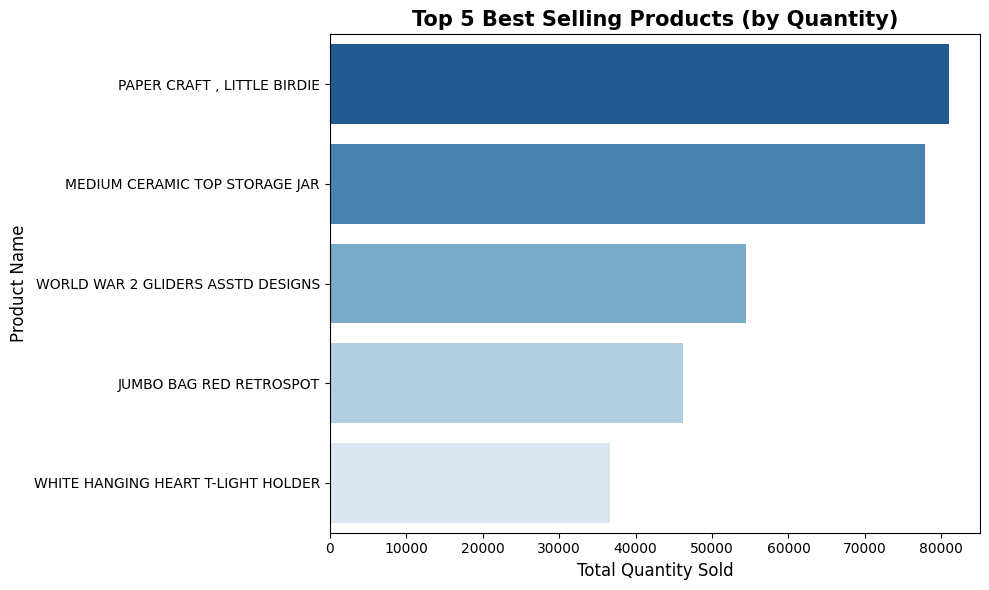

In [ ]:

# 1. Grouping by Description and summing the Quantity
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5).reset_index()

# 2. Plotting the top products
plt.figure(figsize=(10, 6))
sns.barplot(x='Quantity', y='Description', data=top_products, palette='Blues_r')

# 3. Styling
plt.title('Top 5 Best Selling Products (by Quantity)', fontsize=15, fontweight='bold')
plt.xlabel('Total Quantity Sold', fontsize=12)
plt.ylabel('Product Name', fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipython-input-2613818247.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Profit', y='Country', data=country_profit, palette='viridis')


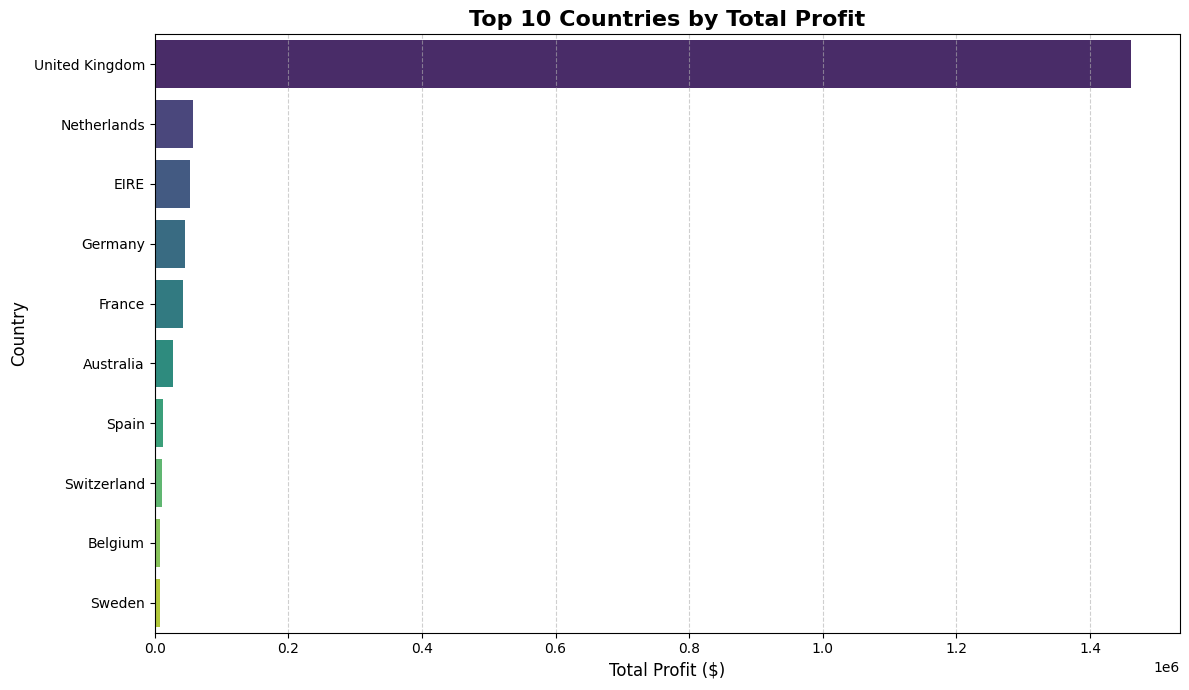

In [ ]:
# 1. Grouping data by Country and summing the profit
country_profit = df.groupby('Country')['Profit'].sum().sort_values(ascending=False).head(10).reset_index()

# 2. Creating the bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x='Profit', y='Country', data=country_profit, palette='viridis')

# 3. Adding professional labels and title
plt.title('Top 10 Countries by Total Profit', fontsize=16, fontweight='bold')
plt.xlabel('Total Profit ($)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# 4. Adding a clean layout and showing the result
plt.tight_layout()
plt.show()